# Sustainability Analysis

## Erasmus+ Traineeship – University of Cantabria

### Project
**Data Science Support for Sustainability Analysis in the Agri-food Sector**

### Supervisor
**Dr. Elisa Baraibar Díez**

### Student
**Ranim Hfaiedh**

---

## Objective of this notebook

This notebook focuses on the sustainability characteristics of large agri-food companies included in the database. The analysis explores the availability of sustainability information, sustainability reports, and other sustainability-related indicators collected during the internship. The results provide the basis for the subsequent Natural Language Processing (NLP) analysis of sustainability reports.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
# ==========================================
# Upload the Excel database
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving DATABASE.xlsx to DATABASE.xlsx


In [3]:
# ==========================================
# Read BigCompanies sheet
# ==========================================

df = pd.read_excel(
    "DATABASE.xlsx",
    sheet_name="BigCompanies"
)

In [4]:
df.head()

,Column1,Company name,Street,Postal code,Locality,Province,Autonomous community,Phone number,Web address,ACTIVE (Y/N),Sustainability reports,sustainable information,Tax ID Number,Legal form,Share capital (thousand EUR),President,Executive Director,"Quotes, doesn't quote, quoted",Last available year,Number of available years,Latest employee count,Stock Market Quote,Operating revenue (thousand EUR),Nb of companies in corporate group,Number of investees,Primary CNAE 2009 code,Secondary code(s) CNAE 2009,Secondary literal(s) CNAE 2009,Primary CNAE 2009 code literal,Group name,Group Description,Group size,English trade description,Activity description,Importer / Exporter
0,1,GREENMED SL,"CALLE MANUEL VIVANCO, 12",12550,ALMASSORA,Castellón,Comunidad Valenciana,+34 96/1742700,www.greenmed.es,yes,no,no,B12457230,Sociedad limitada,57,REVACITRUS SOCIEDAD LIMITADA,AGRIMARBA 2 SL,No cotiza en bolsa,45535,26,1292,No Cotiza en Bolsa,245291.0,0,0,123,4631.0,Comercio al por mayor de frutas y hortalizas,Cultivo de cítricos,012 VL,Cultivos perennes,1325,This company is primarily engaged in processin...,Comercialización de cítricos,Exportador
1,2,AGROPONIENTE NATURAL PRODUCE SL,"CALLE PAISES BAJOS, 1",4710,EL EJIDO,Almería,Andalucía,+34 95/0583002,www.agroponiente.com,yes,yes,yes,B04172862,Sociedad limitada,392,NaN,Don Jorge Reig Berlanga,No cotiza en bolsa,45900,24,1293,No Cotiza en Bolsa,244386.0,33,3,113,4631.0,Comercio al por mayor de frutas y hortalizas,"Cultivo de hortalizas, raíces y tubérculos",011 VL,Cultivos no perennes,1151,This company is engaged in the production and ...,Comercialización de productos hortofruticolas.,Importador / Exportador
2,3,"BORGES AGRICULTURAL & INDUSTRIAL NUTS, S.A. (E...","CALLE FLIX, 29",43205,REUS,Tarragona,Cataluña,+34 97/7309000,www.borges-bain.com,yes,yes,yes,A58410804,Sociedad anonima,9950,NaN,NaN,Dejó de cotizar en bolsa,43982,22,311,No Cotiza en Bolsa,175768.0,0,0,125,127.0,Cultivo de plantas para bebidas,Cultivo de otros árboles y arbustos frutales y...,012,Cultivos perennes,18566,The company is an entity based in Spain that p...,"Producción, procesado y comercialización de fr...",No realiza actividad exterior
3,5,LICUAS SA,"CALLE NANCLARES DE OCA (EDIF. ""A2 PLAZA"" FASE ...",28022,MADRID,Madrid,Madrid,+34 91/3531050,www.licuas.es,yes,no,no,A78066487,Sociedad anonima,4405,Don Joaquin Molpeceres Sanchez,Don Eduardo Rojas Martin,No cotiza en bolsa,45657,33,1045,No Cotiza en Bolsa,112302.0,17,30,130,8020.0,Servicios de sistemas de seguridad,Propagación de plantas,013 VL,Propagación de plantas,51,This company is engaged in the provision of co...,"La construcción o instalación, mantenimiento y...",Importador / Exportador
4,6,EUROPLATANO SA,"CAMINO LOS PALOMARES, 118",38767,LOS LLANOS DE ARIDANE,Santa Cruz de Tenerife,Canarias,+34 92/2401083,www.europlatano.es,yes,no,no,A38303376,Sociedad anonima,139,BALIERAS SL REPR PJ LORENZO SPERANZINI FRANCISCO,Don Carlos Aciego De Mendoza Cabrera,No cotiza en bolsa,44926,23,400,No Cotiza en Bolsa,85174.0,2,1,122,4775.0,Comercio al por menor de productos cosméticos ...,Cultivo de frutos tropicales y subtropicales,012 VL,Cultivos perennes,1325,This establishment operates as an organization...,Envasado y empaquetado de plátanos.,Exportador


# 1. Explore the Sustainability Dataset

Before analysing sustainability indicators, it is essential to understand the structure and quality of the BigCompanies dataset.

In [5]:
df.shape

(385, 35)

### Interpretation

The BigCompanies dataset contains **385 companies** and **35 variables**. These companies represent the subset of large agri-food companies selected from the combined database, focusing on organizations with more than 250 employees. This subset forms the basis for the sustainability analysis conducted in this notebook.

In [6]:
df.columns

Index(['Column1', 'Company name ', 'Street', 'Postal code', 'Locality',
       'Province', 'Autonomous community', 'Phone number', 'Web address',
       'ACTIVE (Y/N)', 'Sustainability reports', 'sustainable information',
       'Tax ID Number', 'Legal form', 'Share capital (thousand EUR)',
       'President', 'Executive Director', 'Quotes, doesn't quote, quoted',
       'Last available year', 'Number of available years',
       'Latest employee count', 'Stock Market Quote',
       'Operating revenue (thousand EUR)',
       'Nb of companies in corporate group', 'Number of investees',
       'Primary CNAE 2009 code', 'Secondary code(s) CNAE 2009',
       'Secondary literal(s) CNAE 2009', 'Primary CNAE 2009 code literal',
       'Group name', 'Group Description', 'Group size',
       'English trade description', 'Activity description',
       'Importer / Exporter'],
      dtype='object')

# 2. Sustainability Overview

This section provides an overview of the sustainability practices of the large agri-food companies included in the dataset. The analysis examines the availability of sustainability reports, sustainability-related information disclosed on company websites, and the activity status of the companies.

In [7]:
# ==========================================
# Company Activity Status
# ==========================================

activity = df["ACTIVE (Y/N)"].value_counts(dropna=False)

activity_summary = pd.DataFrame({
    "Number of Companies": activity,
    "Percentage (%)": round(activity / len(df) * 100, 2)
})

activity_summary

,Number of Companies,Percentage (%)
ACTIVE (Y/N),,
yes,304,78.96
no website,43,11.17
no,38,9.87


### Interpretation

The results indicate that **304 companies (78.96%)** are classified as active. A further **43 companies (11.17%)** could not be assessed because no company website was available, while **38 companies (9.87%)** were classified as inactive. Overall, most of the large companies included in the dataset are currently active, providing a suitable basis for the subsequent sustainability analysis.

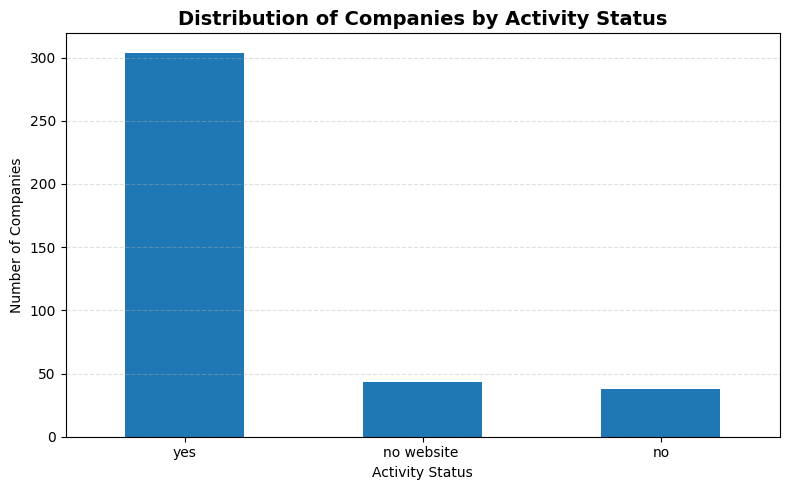

In [9]:
# ==========================================
# Company Activity Status
# ==========================================

plt.figure(figsize=(8,5))

activity.plot(kind="bar")

plt.title(
    "Distribution of Companies by Activity Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Activity Status")
plt.ylabel("Number of Companies")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The bar chart shows that the majority of the large companies (304 out of 385) are currently active. A smaller number of companies (43) could not be evaluated because no official website was available, while only 38 companies were classified as inactive. These results indicate that most of the companies included in the sustainability analysis are active organizations.

## 2.2 Sustainability Reports

This section analyses the availability of sustainability reports published by the large agri-food companies included in the dataset.

In [10]:
# ==========================================
# Sustainability Reports
# ==========================================

reports = df["Sustainability reports"].value_counts(dropna=False)

reports_summary = pd.DataFrame({
    "Number of Companies": reports,
    "Percentage (%)": round(reports / len(df) * 100, 2)
})

reports_summary

,Number of Companies,Percentage (%)
Sustainability reports,,
no,280,72.73
yes,105,27.27


### Interpretation

The results indicate that **105 out of 385 large agri-food companies (27.27%)** have at least one sustainability-related report or document recorded in the dataset, whereas **280 companies (72.73%)** do not. These findings suggest that sustainability disclosure is present among a significant proportion of large companies, although most companies in the dataset do not currently have a recorded sustainability document. This result provides a baseline for the subsequent analyses by sector, region, and company characteristics.

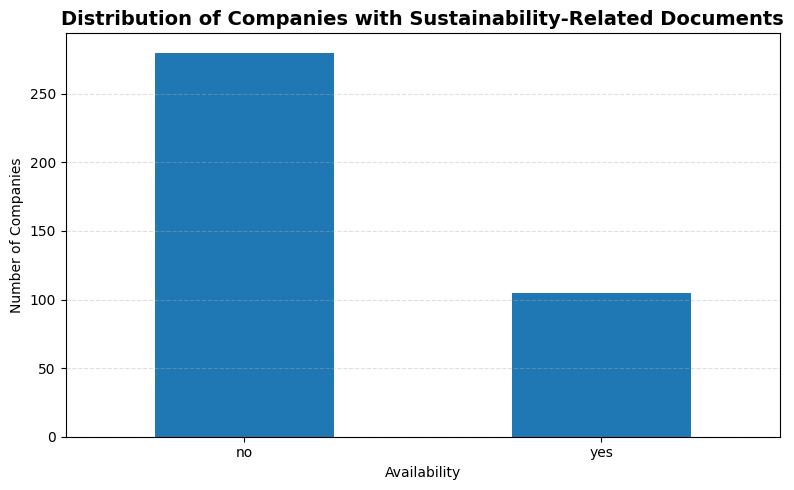

In [11]:
# ==========================================
# Sustainability Reports
# ==========================================

plt.figure(figsize=(8,5))

reports.plot(kind="bar")

plt.title(
    "Distribution of Companies with Sustainability-Related Documents",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Availability")
plt.ylabel("Number of Companies")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The bar chart illustrates that the majority of large agri-food companies in the dataset do not have a recorded sustainability-related document. Nevertheless, **105 companies** have at least one sustainability-related document available, representing approximately **27%** of the sample. This result indicates that sustainability disclosure is present among a considerable number of large companies, although it has not yet become a common practice across the entire sector.

# 3. Sustainability Reporting by Company Characteristics

The following analyses investigate how sustainability-related document availability varies according to different company characteristics, including economic activity, geographical location, company size, and financial indicators. These comparisons provide a deeper understanding of the factors associated with sustainability disclosure.

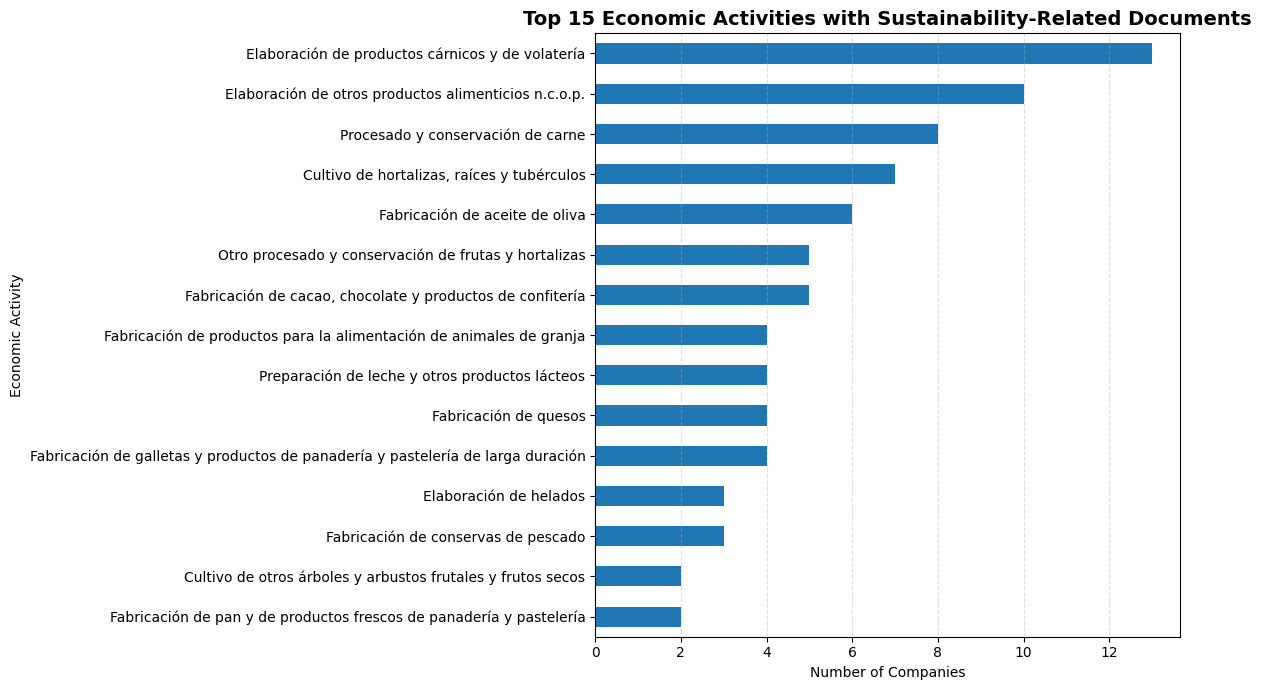

In [12]:
# ==========================================
# Sustainability Documents by Economic Activity
# ==========================================

activity_reports = (
    df[df["Sustainability reports"] == "yes"]
    ["Primary CNAE 2009 code literal"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,7))

activity_reports.sort_values().plot(kind="barh")

plt.title(
    "Top 15 Economic Activities with Sustainability-Related Documents",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Companies")
plt.ylabel("Economic Activity")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The distribution of sustainability-related documents varies across economic activities. The highest number of companies with sustainability-related documents is observed in the manufacture of meat and poultry products, followed by the manufacture of other food products and meat processing and preservation. Other important activities include vegetable cultivation, olive oil production, and fruit and vegetable processing. These results suggest that sustainability disclosure is more common in some agri-food subsectors than in others.

## 3.2 Sustainability-Related Documents by Autonomous Community

This analysis examines the geographical distribution of companies with sustainability-related documents across the Spanish autonomous communities.

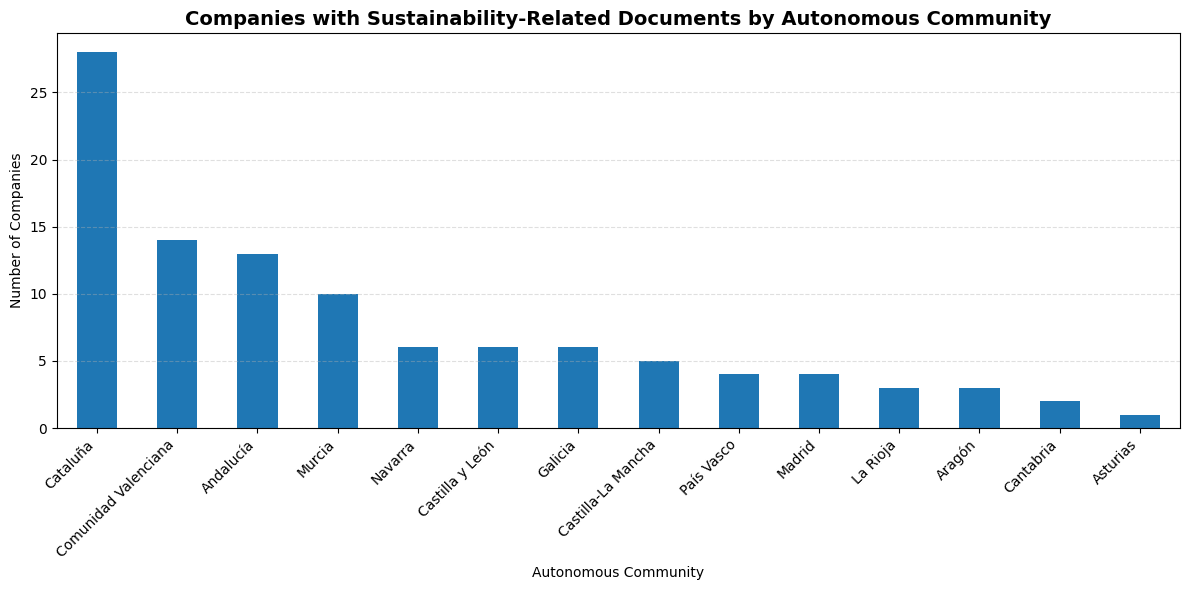

In [13]:
# ==========================================
# Sustainability Documents by Autonomous Community
# ==========================================

community_reports = (
    df[df["Sustainability reports"] == "yes"]
    ["Autonomous community"]
    .value_counts()
)

plt.figure(figsize=(12,6))

community_reports.plot(kind="bar")

plt.title(
    "Companies with Sustainability-Related Documents by Autonomous Community",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Autonomous Community")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The geographical distribution of companies with sustainability-related documents is uneven across the Spanish autonomous communities. Catalonia has the highest number of companies with sustainability-related documents, followed by the Valencian Community, Andalusia, and Murcia. These regions represent important agri-food production areas in Spain, which may contribute to the higher level of sustainability disclosure observed in the dataset.

# 4. Company Size and Sustainability Disclosure

This section investigates whether companies with sustainability-related documents differ from those without such documents in terms of employee count and operating revenue.

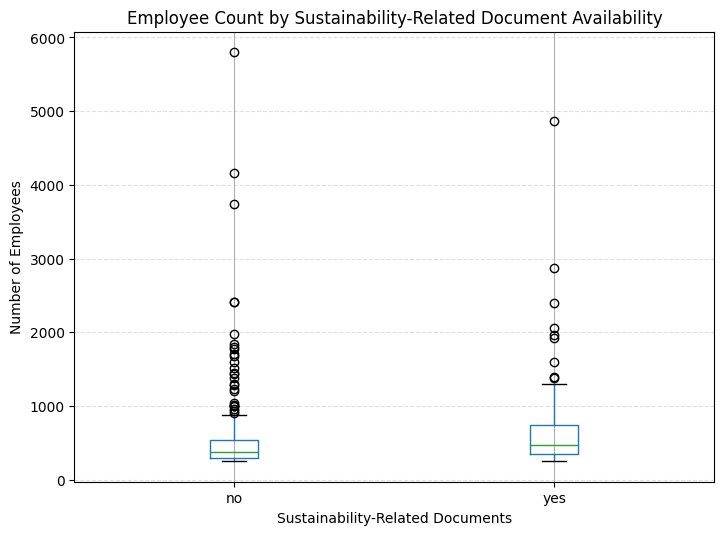

In [14]:
# ==========================================
# Employee Count by Sustainability Documents
# ==========================================

df.boxplot(
    column="Latest employee count",
    by="Sustainability reports",
    figsize=(8,6)
)

plt.title("Employee Count by Sustainability-Related Document Availability")
plt.suptitle("")

plt.xlabel("Sustainability-Related Documents")
plt.ylabel("Number of Employees")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Interpretation

The boxplot indicates that companies with sustainability-related documents generally employ more people than companies without such documents. The median employee count is higher for companies with sustainability-related documents, and their distribution extends to larger workforce sizes. Both groups contain several outliers, representing very large companies with exceptionally high numbers of employees. Overall, the results suggest that larger companies are more likely to disclose sustainability-related information.

## 4.2 Operating Revenue and Sustainability Disclosure

This analysis compares the operating revenue of companies with and without sustainability-related documents to explore whether companies with higher revenues are more likely to disclose sustainability information.

In [15]:
# ==========================================
# Operating Revenue by Sustainability Documents
# ==========================================

df.groupby("Sustainability reports")["Operating revenue (thousand EUR)"].describe()

,count,mean,std,min,25%,50%,75%,max
Sustainability reports,,,,,,,,
no,279.0,135441.548387,257851.669223,591.0,29788.0,72338.0,138952.0,2927513.0
yes,105.0,356835.742857,395187.509449,4122.0,122306.0,209263.0,520224.0,2688678.0


### Interpretation

The descriptive statistics indicate that companies with sustainability-related documents are generally larger in terms of operating revenue than companies without such documents. Companies with sustainability-related documents have a median operating revenue of **209,263 thousand EUR**, compared with **72,338 thousand EUR** for companies without sustainability-related documents. Similarly, the average operating revenue is substantially higher for companies with sustainability-related documents (**356,836 thousand EUR**) than for companies without (**135,442 thousand EUR**). These findings suggest that companies with greater financial resources are more likely to publish sustainability-related documents.

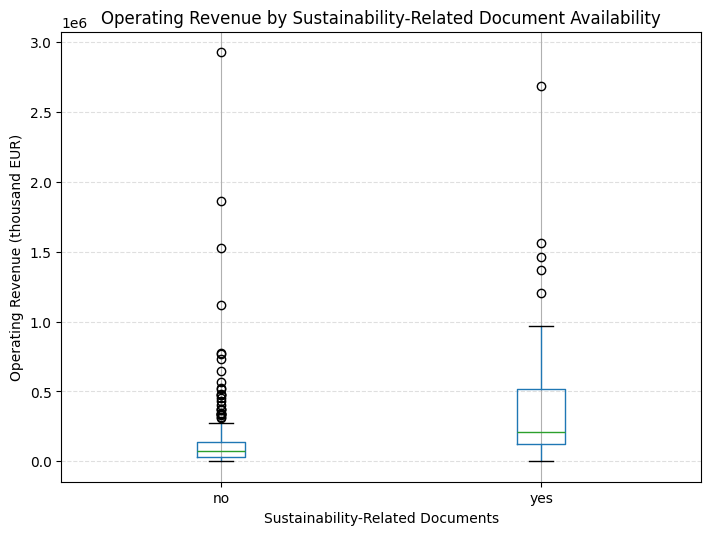

In [16]:
# ==========================================
# Operating Revenue by Sustainability Documents
# ==========================================

df.boxplot(
    column="Operating revenue (thousand EUR)",
    by="Sustainability reports",
    figsize=(8,6)
)

plt.title("Operating Revenue by Sustainability-Related Document Availability")
plt.suptitle("")

plt.xlabel("Sustainability-Related Documents")
plt.ylabel("Operating Revenue (thousand EUR)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Interpretation

The boxplot shows that companies with sustainability-related documents generally report higher operating revenues than companies without such documents. The median operating revenue is noticeably higher for companies with sustainability-related documents, and the overall distribution is shifted towards larger revenue values. Both groups contain several extreme outliers, corresponding to very large companies with exceptionally high revenues. Overall, the results suggest that companies with greater financial capacity are more likely to disclose sustainability-related information.

# 5. Statistical Comparison

To complement the descriptive analysis, statistical tests are performed to evaluate whether companies with sustainability-related documents differ significantly from those without such documents in terms of employee count and operating revenue.

In [18]:
from scipy.stats import mannwhitneyu

# Employee count
employees_yes = df[df["Sustainability reports"]=="yes"]["Latest employee count"].dropna()
employees_no = df[df["Sustainability reports"]=="no"]["Latest employee count"].dropna()

u_emp, p_emp = mannwhitneyu(employees_yes, employees_no)

print("Employee Count")
print("U statistic:", u_emp)
print("p-value:", p_emp)

Employee Count
U statistic: 18660.0
p-value: 4.6663020193662596e-05


### Interpretation

The Mann–Whitney U test indicates a statistically significant difference in employee count between companies with and without sustainability-related documents (p < 0.05). This result supports the observation that companies with sustainability-related documents generally have larger workforces.

In [19]:
# Operating revenue

revenue_yes = df[df["Sustainability reports"]=="yes"]["Operating revenue (thousand EUR)"].dropna()

revenue_no = df[df["Sustainability reports"]=="no"]["Operating revenue (thousand EUR)"].dropna()

u_rev, p_rev = mannwhitneyu(revenue_yes, revenue_no)

print("Operating Revenue")
print("U statistic:", u_rev)
print("p-value:", p_rev)

Operating Revenue
U statistic: 22587.0
p-value: 2.6347000305515457e-16


### Interpretation

The Mann–Whitney U test indicates a statistically significant difference in operating revenue between companies with and without sustainability-related documents (p < 0.05). This result supports the observation that companies with sustainability-related documents generally report higher operating revenues.

# 6. Key Findings

The sustainability analysis of large agri-food companies led to the following main findings:

- Around 27% of the companies have at least one sustainability-related document available.
- Sustainability-related documents are more common in specific agri-food sectors, particularly food manufacturing activities.
- Catalonia, the Valencian Community, and Andalusia contain the highest numbers of companies with sustainability-related documents.
- Companies with sustainability-related documents generally have larger workforces than companies without such documents.
- Companies with sustainability-related documents also tend to report higher operating revenues.
- The Mann–Whitney U tests confirmed that the differences in employee count and operating revenue between the two groups are statistically significant (p < 0.05).

These findings indicate that sustainability disclosure is associated with larger company size and greater financial capacity. The resulting dataset provides a strong foundation for the Natural Language Processing (NLP) analysis presented in the next notebook.